In [1]:
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from typing import TypedDict, Annotated,List
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langgraph.graph import START, END,StateGraph
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv  
import os
import re
import time
import subprocess
import tracemalloc
import psutil
from huggingface_hub import InferenceClient
# from google import genai
from openai import OpenAI
from dotenv import load_dotenv
from groq import Groq
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()

/Users/nisargbhatia/Desktop/Sem6/BMP_Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
class TranslationState(TypedDict):
    input_code: str
    inp_lang: str
    target_lang: str
    input_path: str         # NEW — legacy code written to disk, set by setup_node
    working_filepath: str   # NEW — server-side temp file, set once in translate_node
    translated_code: str
    feedback: list          # filled by run_tests node
    navigator_analysis: str # filled by navigator node
    attempt_count: int
    max_attempts: int
    passed: bool
    legacy_output:str
    translated_output:str

Step 1 — Define your State
Before any nodes, decide what data flows through the graph. Looking at your run_benchmark, the things that get read/written across phases are: input_code, inp_lang, target_lang, translated_code, test_results/feedback, attempt_count, max_attempts, passed. Define this as a TypedDict (this is your single source of truth the whole graph reads/writes — same role as results dict in your notebook, but shared across nodes instead of local to one function).

In [3]:
import tempfile

def get_working_filepath(target_lang: str) -> str:  #This is used for temporary file creation on server side
    ext = get_file_extension(target_lang)
    fd, path = tempfile.mkstemp(suffix=ext)
    os.close(fd)
    return path

def get_file_extension(language):
    extensions = {"python": ".py", "c": ".c", "cpp": ".cpp", "java": ".java", "go": ".go", "rust": ".rs","fortran": ".f"}
    return extensions.get(language.lower(), ".txt")

def extract_code(llm_output: str) -> str:
    code = llm_output.strip()
    fence_match = re.search(r"```[\w+-]*\n([\s\S]*?)\n```", code)
    if fence_match:
        return fence_match.group(1).strip()
    code = re.sub(r"^```[\w+-]*", "", code)
    code = re.sub(r"```$", "", code)
    return code.strip()

def normalize(output):
    """Normalize output by standardizing spaces and floats for cross-language matching."""
    # Convert to lowercase to avoid case-sensitivity issues
    output = output.lower()
    
    # Process line by line
    lines = [line.strip() for line in output.split('\n')]
    
    normalized_lines = []
    for line in lines:
        if not line:
            continue
            
        # Replace multiple spaces with a single space
        line = re.sub(r'\s+', ' ', line)
        
        # Normalize floats: Strip trailing zeros (e.g., 5.00000000 -> 5.0)
        # Keeps precision intact for exact decimals but normalizes padding
        line = re.sub(r'(\d+\.\d*?[1-9])0+\b', r'\1', line)  # 5.1200 -> 5.12
        line = re.sub(r'(\d+)\.0+\b', r'\1.0', line)         # 5.0000 -> 5.0
        
        normalized_lines.append(line)
        
    return '\n'.join(normalized_lines)

In [4]:
# Add this near your other client initializations
# gemini_api_key = os.getenv("GEMINI_API_KEY")
# gemini_client = genai.Client(api_key=gemini_api_key) if gemini_api_key else None

# Initialize API Clients
groq_client = Groq(api_key=os.getenv("GROQ_API_KEY"))
hf_api_key = os.getenv("HF_API_KEY")
hf_client = InferenceClient(token=hf_api_key) if hf_api_key else None

# Initialize GitHub Models using the standard OpenAI library
github_client = OpenAI(
    base_url="https://models.inference.ai.azure.com",
    api_key=os.getenv("GITHUB_API_KEY")
)

# OpenRouter acts exactly like OpenAI, just point it to their base URL
openrouter_client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY")
)

In [5]:
def generate_code(prompt, provider, model_id):
    """Universal function to call different LLM APIs dynamically."""
    provider = provider.strip().lower()

    try:
        if provider == "groq":
            response = groq_client.chat.completions.create(
                messages=[{"role": "user", "content": prompt}],
                model=model_id,
                temperature=0.1,
            )
            return response.choices[0].message.content or ""

        elif provider == "gemini":
            if not gemini_client:
                raise ValueError("Gemini client not initialized. Check your API key.")
            response = gemini_client.models.generate_content(
                model=model_id,
             contents=prompt,
            )
            return response.text or ""
        
        elif provider == "github":
            max_retries = 3
            for attempt in range(max_retries):
                try:
                    response = github_client.chat.completions.create(
                        messages=[{"role": "user", "content": prompt}],
                        model=model_id,
                        temperature=0.1,
                    )
                    return response.choices[0].message.content or ""
                except Exception as e:
                    if "429" in str(e) and attempt < max_retries - 1:
                        print(f"    ⏳ GitHub limit hit. Cooling down for 10s...")
                        time.sleep(10)
                    else:
                        print(f"    ❌ GitHub Error: {str(e)}")
                        return ""
            return ""
        
        elif provider == "openrouter":
            max_retries = 3
            for attempt in range(max_retries):
                try:
                    response = openrouter_client.chat.completions.create(
                        messages=[{"role": "user", "content": prompt}],
                        model=model_id,
                        temperature=0.1,
                        timeout=45.0
                    )
                    # DEFENSIVE CHECK: Prevent NoneType crashes
                    if hasattr(response, 'choices') and response.choices:
                        return response.choices[0].message.content or ""
                    else:
                        print(f"    ⚠️ OpenRouter returned empty object. Retrying...")
                        time.sleep(5)
                except Exception as e:
                    if "429" in str(e) and attempt < max_retries - 1:
                        print(f"    ⚠️ OpenRouter busy. Retrying in 5s (Attempt {attempt + 1})...")
                        time.sleep(5)
                    else:
                        print(f"    ❌ OpenRouter Error: {str(e)}")
                        return ""
            
            # THE FIX: If it tries 3 times and still gets empty objects, safely return empty string
            print(f"    ❌ OpenRouter Failed all retries.")
            return ""

        elif provider == "huggingface":
            if not hf_client:
                raise ValueError("HF_API_KEY not found or client not initialized.")
            
            try:
                # The official SDK handles the URLs, headers, and routing automatically
                response = hf_client.chat_completion(
                    model=model_id,
                    messages=[{"role": "user", "content": prompt}],
                    max_tokens=2048,
                    temperature=0.1
                )
                return response.choices[0].message.content or ""
            
            except Exception as e:
                error_msg = str(e)
                if "503" in error_msg or "loading" in error_msg.lower():
                    print(f"    ⏳ HF Model {model_id} is currently waking up on their servers. Try again in 20s.")
                else:
                    print(f"    ❌ HF Error: {error_msg}")
                return ""
            
            res = requests.post(url, headers=headers, json=payload, timeout=120)
            if res.status_code == 200:
                return res.json()["choices"][0]["message"]["content"]
            elif res.status_code == 503:
                print("    ⚠️ HF Model is loading, skipping for now...")
                return ""
            else:
                print(f"    ❌ HF Error: {res.status_code} - {res.text}")
                return ""

        else:
            raise ValueError(f"Unsupported provider: {provider}")

    except Exception as e:
        print(f"    ❌ API Error ({provider} - {model_id}): {str(e)}")
        return ""

In [6]:
def parse_tests(test_file):
    if not os.path.exists(test_file): return []
    with open(test_file, "r") as f:
        lines = f.readlines()
    if not lines: return []
    t = int(lines[0].strip())
    tests = []
    for i in range(1, t + 1):
        tests.append(lines[i].strip().replace('\\n', '\n') + '\n')
    return tests

def parse_tests_from_string(content: str) -> list:
    lines = content.splitlines(keepends=True) 
    if not lines: return []
    t = int(lines[0].strip())
    tests = []
    for i in range(1, t + 1):
        tests.append(lines[i].strip().replace('\\n', '\n') + '\n')
    return tests
def run_program(language, filepath, input_data, timeout=5):
    """A unified runner that returns (output, error_message)."""
    lang = language.lower()
    if not os.path.exists(filepath): return "", "File not found"
    
    try:
        if lang == "python":
            res = subprocess.run(["python", filepath], input=input_data, text=True, capture_output=True, timeout=timeout)
            return res.stdout.strip(), res.stderr if res.returncode != 0 else None
            
        elif lang in ["c", "cpp", "c++"]:
            exe = "./a.out"
            compiler = "gcc" if lang == "c" else "g++"
            comp = subprocess.run([compiler, filepath, "-o", exe], capture_output=True, text=True)
            if comp.returncode != 0: return "", f"Compile error: {comp.stderr}"
            res = subprocess.run([exe], input=input_data, text=True, capture_output=True, timeout=timeout)
            return res.stdout.strip(), res.stderr if res.returncode != 0 else None
            
        # MISSING FORTRAN BLOCK RESTORED HERE
        elif lang in ["fortran", "f77", "f90"]:
            exe = "./a.out"
            comp = subprocess.run(["gfortran", filepath, "-o", exe], capture_output=True, text=True)
            if comp.returncode != 0: return "", f"Compile error: {comp.stderr}"
            res = subprocess.run([exe], input=input_data, text=True, capture_output=True, timeout=timeout)
            return res.stdout.strip(), res.stderr if res.returncode != 0 else None

        elif lang == "java":
            file_dir = os.path.dirname(filepath) or "."
            file_name = os.path.basename(filepath)
            with open(filepath, 'r') as f: java_code = f.read()
            class_match = re.search(r'public\s+class\s+(\w+)', java_code)
            classname = class_match.group(1) if class_match else file_name.replace(".java", "")
            comp = subprocess.run(["javac", file_name], cwd=file_dir, capture_output=True, text=True)
            if comp.returncode != 0: return "", f"Compile error: {comp.stderr}"
            res = subprocess.run(["java", classname], input=input_data, text=True, capture_output=True, timeout=timeout, cwd=file_dir)
            return res.stdout.strip(), res.stderr if res.returncode != 0 else None
            
    except subprocess.TimeoutExpired:
        return "", "Timeout"
    except Exception as e:
        return "", str(e)
    
    return "", f"Language {lang} not supported in runner"

In [7]:


def setup_node(state: TranslationState, config: RunnableConfig) -> dict:
    ...
    input_path = get_working_filepath(state["inp_lang"])  # reuse same helper, just keyed on inp_lang's extension
    with open(input_path, "w") as f:
        f.write(state["input_code"])

    return {
        "input_path": input_path,
        "max_attempts": config["configurable"].get("max_attempts", 5),  # default matches your notebook's max_attempts=5
    }

In [8]:
def translate_node(state: TranslationState, config: RunnableConfig) -> dict:
    # Pull static config (provider, model_id) the same way you'll pull tests later
    provider = config["configurable"]["provider"]
    model_id = config["configurable"]["model_id"]

    # TODO: build the prompt — this is your existing Phase 1 prompt string,
    # verbatim, just substitute state["inp_lang"], state["target_lang"],
    # and state["input_code"] instead of the local variables you used before
    inp_lng=state['inp_lang']
    target_lng=state['target_lang']
    input_code=state['input_code']
    prompt = f''' You are an exceptionally intelligent coding assistant acting as a literal syntax compiler for code translation. You consistently deliver accurate translations while maintaining the original code's exact functionality, output format, and numerical precision.

Please translate this {inp_lng} code to {target_lng}. Follow these CRITICAL guidelines:

1) **COMPLETE PROGRAM**: Translate the ENTIRE program including ALL subroutines/functions/methods, initialization, calculations, and display/output routines. Do NOT omit any functions or return partial code. The output must be a complete, executable program.

2) **LITERAL MATHEMATICS (NO HALLUCINATIONS)**: Translate mathematical operations, formulas, and variable assignments EXACTLY as they appear in the source code. 
   - DO NOT substitute formulas from your own knowledge. 
   - Preserve all numeric constants and precision multipliers exactly.
   - Example: `0.5 * dt * dx` stays as `0.5 * dt * dx` (do not simplify differently).

3) **EXACT I/O & PROMPTS**: Every input must produce IDENTICAL output byte-for-byte in strict test environments.
   - Read inputs dynamically in the same order as the original. NEVER hardcode test values.
   - Preserve every single print statement, prompt string, and delimiter exactly.
   - Do NOT add extra newlines unless they exist in the source. Handle line-by-line input correctly.

4) **DISPLAY/PRINT LOOPS WITH STRIDE**: When translating loops that print values with a stride pattern (e.g., printing every nth element):
   - Preserve the stride/step calculation precisely.
   - DO NOT print every single value if the original prints selectively—this guarantees test failures.
   - Translate format specifications to exact target equivalents (e.g., Fortran `format(f10.4,' | ',f15.2)` becomes Python `print(f"{{val1:10.4f}} | {{val2:15.2f}}")`).

5) **OUTPUT FORMAT**: Preserve EXACT formatting:
   - Decimal precision (2 decimals, 4 decimals, etc.).
   - Field widths, padding, string formatting, and alignment.

6) **ARRAYS & INDEXING (CRITICAL BOUNDS)**: 
   - Identify the source language's indexing system (e.g., 1-based vs 0-based).
   - Convert array access appropriately for the target language.
   - strictly adjust loop boundaries to prevent off-by-one errors. If a source loop runs exactly 19 times, the target loop MUST run exactly 19 times.

7) **STRUCTURE**: 
   - Maintain overall organization (subroutines/functions/methods, main logic/entry point).
   - Use appropriate language constructs (classes if needed for state management).
   - Keep method/function names and parameter names clear and meaningful.

8) **NUMERICAL OPERATIONS**: 
   - Preserve numeric types (integer, float, double precision).
   - Preserve integer division semantics strictly according to the source language rules.
   - Preserve floating-point precision and rounding behavior.

9) **LANGUAGE-SPECIFIC CONVERSIONS**: 
   - Translate language constructs appropriately (e.g., COMMON blocks to classes, modules to namespaces).
   - Convert language-specific keywords and syntax to exact target language equivalents.

10) **LIBRARIES & IMPORTS**: Include all necessary imports/headers/libraries needed for the algorithms to run.

11) **OUTPUT**: Return ONLY the complete translated code in a single code block. NO explanations, NO extra text, NO incomplete snippets.

12) **DO NOT**: 
    - Optimize or refactor algorithms.
    - Change output stride/sampling patterns.
    - Omit any functions, subroutines, or methods.
    - Change the program flow or control structure.
13) **STRICT I/O SEPARATION**: 
    - In Python, NEVER put prompt strings inside the `input()` function (e.g., NO `input("Enter value:")`).
    - You MUST separate prompts and inputs. Use `print("Enter value:")` followed by `val = input()`. This perfectly mimics Fortran's `print *` newline behavior.
    
14) **NO HELPFUL TEXT**: Do not add helpful text like `(y/n)` or `...` to the prompts. Translate the strings exactly as they appear in the original source, character for character.
15) MULTI-VARIABLE INPUTS (CRITICAL): Fortran's read(*,*) a, b reads tokens across multiple newlines. Python's input().split() only reads a single line. You MUST perfectly mimic Fortran by printing the original prompt string ONCE, followed by separate input() calls for each variable.
BAD: a, b = input("Enter a and b: ").split()
GOOD: > print("Enter a and b: ")
a = type(input().strip())
b = type(input().strip())

"16) **DIVISION BY ZERO (IEEE 754)**: Fortran natively handles division by zero by evaluating to `Infinity` and propagating `NaN`s, whereas Python crashes with `ZeroDivisionError`. If a formula may divide by zero, you MUST handle it by returning `float('inf')` (or `-inf` based on the numerator) to perfectly match Fortran's behavior. NEVER add an epsilon (e.g., `+ 1e-6`) or return 0, as this causes numerical explosions and OverflowErrors in physics loops.\n",

Code to Translate: {input_code} '''

    raw_output = generate_code(prompt, provider, model_id)
    translated_code = extract_code(raw_output)

    working_filepath = get_working_filepath(state["target_lang"])
    with open(working_filepath, "w") as f:
        f.write(translated_code)
    '''One thing to flag for later (not now): since working_filepath is a real file on the server's disk, 
you'll eventually want cleanup logic — delete it once a translation run reaches END (success or max-attempts-exhausted), 
so temp files don't pile up once this is hosted and getting real traffic.
 Worth a TODO comment, not a blocker right now.
 '''
    return {
    "translated_code": translated_code,
    "working_filepath": working_filepath,
    "attempt_count": 0,
}



In [9]:
def run_tests_node(state: TranslationState, config: RunnableConfig) -> dict:
    tests = config["configurable"]["tests"]

    feedback = []
    legacy_blocks = []
    translated_blocks = []
    for i, input_data in enumerate(tests, 1):
        legacy_out, _ = run_program(state["inp_lang"], state["input_path"], input_data)
        translated_out, err = run_program(state["target_lang"], state["working_filepath"], input_data)
        # ... rest unchanged

        norm_legacy = normalize(legacy_out)
        norm_translated = normalize(translated_out)
        legacy_blocks.append(f"--- Test {i} ---\n{norm_legacy}")
        translated_blocks.append(f"--- Test {i} ---\n{norm_translated}")

        if err or norm_legacy != norm_translated:
            def truncate_text(text, limit=1000):
                    if not text: return ""
                    if len(text) <= limit: return text
                    return text[:200] + "\n... [TRUNCATED] ...\n" + text[-800:]

            feedback.append({
                    "test": i, 
                    "input": input_data.replace('\n', '\\n'), 
                    "expected": truncate_text(norm_legacy), 
                    "actual": truncate_text(norm_translated) if not err else f"ERROR: {truncate_text(err)}"
                })
            pass

    return {
        "feedback": feedback,
        "passed": len(feedback) == 0,
        "legacy_output":"\n".join(legacy_blocks),
        "translated_output":"\n".join(translated_blocks)
    }

In [10]:
def navigator_node(state: TranslationState, config: RunnableConfig) -> dict:
    provider = config["configurable"]["provider"]
    model_id = config["configurable"]["model_id"]
    
    feedback=state['feedback']
    inp_lng=state['inp_lang']
    input_code=state['input_code']
    translated_code=state['translated_code']
    target_lng=state['target_lang']
    nav_prompt = f'''You are an expert code translation debugging assistant. Analyze failed test cases and identify the ROOT CAUSE of differences between the {inp_lng} and {target_lng} code.

ANALYZE THE FOLLOWING FATAL ERRORS:
1. **Dropped I/O**: Did the code skip reading a variable entirely?
2. **NameError**: Did a subroutine try to accept variables that weren't defined yet?
3. **SyntaxError (Global/Parameter)**: Did the code declare a variable as `global` while also passing it as a function parameter?
4. **ValueError (unpacking)**: Did Python use `.split()` on a single line when inputs are on multiple lines?
5. **Off-By-One Bounds**: Did a loop start at 1 instead of 0, skipping the initial state?
6. **Concatenated Prompts**: Did the diff show multiple prompts merged onto one line (e.g., `+ prompt 1 -> prompt 2 ->`)? This means the LLM incorrectly used `input("prompt")` instead of `print()`.
7. **Missing Data Rows**: Did Python print the first and last values but skip the middle ones? Check the display loop's stride calculation (e.g., `max(1, n//20)`).

Provide STRICT JSON with actionable fix hints:
{{
  "error_summary": "...",
  "affected_lines": "...",
  "root_cause": "...",
  "fix_hints": ["hint 1", "hint 2"]
}}

Failed Test Case(s):
{feedback}

Legacy Code ({inp_lng}):
{input_code}

Translated Code ({target_lng}):
{translated_code}
'''

    navigator_raw = generate_code(nav_prompt, provider, model_id)

    # Same JSON-extraction fallback as your original
    json_match = re.search(r'\{[\s\S]*\}', navigator_raw or "")
    navigator_analysis = json_match.group(0) if json_match else (navigator_raw or "").strip()

    return {"navigator_analysis": navigator_analysis}


def driver_node(state: TranslationState,config: RunnableConfig) -> dict:
    provider = config["configurable"]["provider"]
    model_id = config["configurable"]["model_id"]
    target_lng=state['target_lang']
    inp_lng=state['inp_lang']
    input_code=state['input_code']
    translated_code=state['translated_code']
    navigator_analysis=state['navigator_analysis']
    feedback=state['feedback']

    driver_prompt = f'''The translated {target_lng} code failed the test cases against the original {inp_lng} code.
**Original Legacy Code ({inp_lng}):**
{input_code}
**Current Translated Code to Fix ({target_lng}):**
{translated_code}
Navigator Analysis:
{navigator_analysis}

Failed Tests:
{feedback}

CRITICAL FIX REQUIREMENTS:
1. **Apply Navigator Fixes**: Implement the exact logic and boundary fixes identified by the Navigator.
2. **DO NOT HARDCODE VALUES**: The code must continue to read from standard input and process dynamic test cases. Hardcoding to pass a specific test is strictly prohibited.
3. **PRESERVE ENTIRE STRUCTURE**: You must return the FULL, runnable program, including all imports, initializations, standard input reading, and printing. Do not omit or truncate any functions.
4. **EXACT FUNCTIONALITY**: Do not change the underlying algorithm or overall structure.
5. **BYTE-FOR-BYTE MATCH**: Fix the output formatting, precision, spacing, and loop bounds so the output matches the expected test output identically.
6. FIXING VALUEERRORS (I/O): If you see ValueError: not enough values to unpack, it means the test case provided inputs on multiple newlines. Fix this by explicitly reading across multiple lines (e.g., calling input().strip() sequentially). DO NOT split the original print() statement into multiple new prompt strings. You must print the exact original string once, then capture the variables.
7. INTERLEAVED I/O RULE: Legacy Fortran frequently interleaves reading from the terminal (read(5,*)) and reading from external files (open(1...), read(1,*)). When translating to Python, or when suggesting fixes for Python input handling, you MUST NOT use sys.stdin.read(), sys.stdin.readlines(), or sys.stdin iterators. You must use sequential input().strip() calls for terminal inputs to ensure the standard input buffer is perfectly preserved while the external file is being read.

Return ONLY the fully corrected, executable {target_lng} code in a single code block. NO explanations, NO markdown outside the code block.'''

    candidate_code = extract_code(generate_code(driver_prompt, provider, model_id))

    # Mirrors: `if not candidate_code: continue` — but a graph node can't
    # "continue" a Python loop. Simplest equivalent: if empty, just keep
    # the previous translated_code unchanged (don't overwrite with garbage)
    new_code = candidate_code if candidate_code else state["translated_code"]

    with open(state["working_filepath"], "w") as f:
        f.write(new_code)

    return {
        "translated_code": new_code,
        "attempt_count": state["attempt_count"] + 1,
    }

In [11]:
def route_after_tests(state: TranslationState) -> str:
    if not state["translated_code"].strip(): return "end"
    if state["passed"]:
        return "end"
    if state["attempt_count"] >= state["max_attempts"]:
        return "end"
    return "fix"

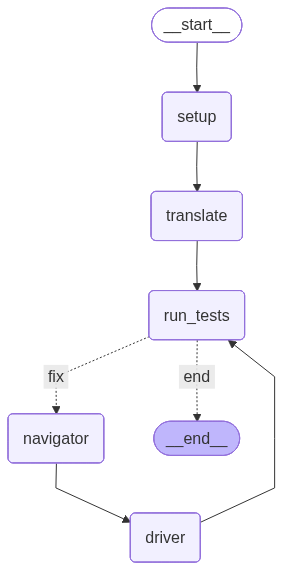

In [12]:
graph = StateGraph(TranslationState)

graph.add_node("setup", setup_node)
graph.add_node("translate", translate_node)
graph.add_node("run_tests", run_tests_node)
graph.add_node("navigator", navigator_node)
graph.add_node("driver", driver_node)

graph.set_entry_point("setup")
graph.add_edge("setup", "translate")
graph.add_edge("translate", "run_tests")

graph.add_conditional_edges(
    "run_tests",
    route_after_tests,
    {"end": END, "fix": "navigator"}
)

graph.add_edge("navigator", "driver")
graph.add_edge("driver", "run_tests")   # loop back

checkpointer = InMemorySaver()
app = graph.compile(checkpointer=checkpointer)
app

In [13]:
import uuid

folder_path = "Sample_Codes/Physics_Sample_Codes/Lorenz_Map/"
input_path = os.path.join(folder_path, "lorenz_map.f")
test_file = os.path.join(folder_path, "tests.txt")

input_code = open(input_path, "r").read()

thread_id = str(uuid.uuid4())

result = app.invoke(
    {
        "input_code": input_code,
        "inp_lang": "fortran",
        "target_lang": "python",
    },
    config={
        "configurable": {
            "thread_id": thread_id,
            "provider": "groq",
            "model_id": "llama-3.3-70b-versatile",
            "tests": parse_tests(test_file),
        }
    }
)

print(result["translated_code"])
print(f"Passed: {result['passed']}, Attempts used: {result['attempt_count']}")

import numpy as np

def initialize(x, y, z, t, sigma, r, b, dt, lsym, nsym, k, n, m, nout):
    print("Lorenz model: Euler (1) or Runge-Kutta [2nd ord] (2)?")
    m = int(input())
    print("parameters: sigma, r, b ?")
    sigma, r, b = map(float, input().split())
    print("initial x, y, z ?")
    x[0], y[0], z[0] = map(float, input().split())
    print("time step, how many steps ?")
    dt, n = map(float, input().split())
    t[0] = 0
    print("record output to a file [out.lorenz] ?")
    ans = input()
    if ans == 'y':
        nout = 1
    else:
        nout = 2
        print("plot [z vs t,z vs x](1) or [x , y vs t](2)?")
        k = int(input())
        if k not in [1, 2]:
            print("must select 1 or 2 ...")
            exit()
        print("set line, symbol?")
        ans = input()
        if ans == 'y':
            print("lsym, nsym ? -> ")
            lsym, nsym = map(float, input().split())
        else:
            lsym = 0
            nsym = 1
    return sigma, r, b

In [14]:
result

{'input_code': 'c\nc Simulation of the Lorenz map\nc        - Euler or Runge-Kutta (2nd order usual one)\nc Program to accompany "Computational Physics" by N. Giordano and H. Nakanishi\nc Line 89 was originally incorrect, corrected to "t1 = t(i-1)+0.5*dt"\nc\n      program lorenz\nc\nc       Declare the arrays we will need\nc\n      implicit real*8 (a-h,o-z)\n      dimension x(500003),y(500003),z(500003),t(500003)\nc\nc       Use subroutines to do the work\nc\n      call initialize(x,y,z,t,sigma,r,b,dt,lsym,nsym,k,nstep,m,nout)\n      call calculate(x,y,z,t,sigma,r,b,dt,lsym,nsym,k,nstep,m)\n      if(nout.eq.1) then\n          open(1,file=\'out.lorenz\')\n          rewind(1)\n          do 10 i=1,nstep\n              write(1,15) t(i),x(i),y(i),z(i)\n10        continue\n          close(1)\n15        format(1x,1p,4(e12.5,1x))\n      else\n          call display(x,y,z,t,sigma,r,b,dt,lsym,nsym,k,nstep,m)\n      endif\n      stop\n      end\nc\n      subroutine initialize(x,y,z,t,sigma,r,b,d